In [1]:
#KAVIBHARATHI K
#212224220045

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

In [4]:
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

Processing...
Done!


In [5]:
def show_sample_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(5, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0)
        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis('off')
    plt.show()

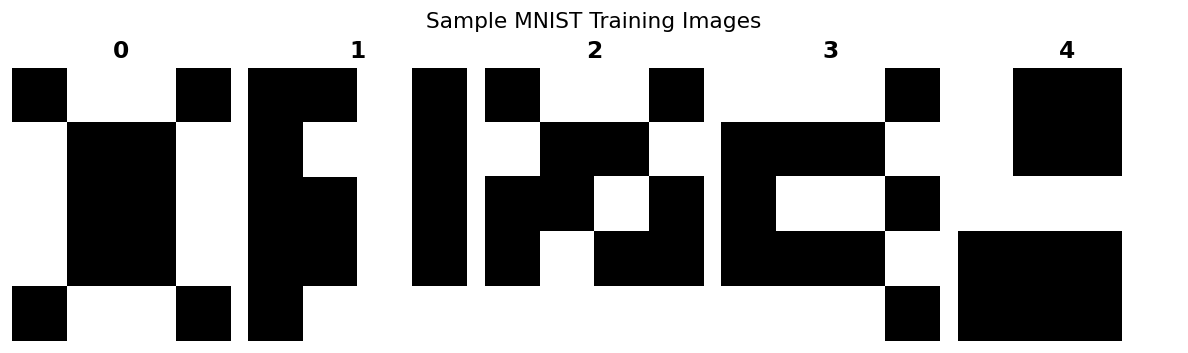

In [6]:
show_sample_images(train_dataset)

In [7]:
print(f"Total number of training samples: {len(train_dataset)}")
first_image, label = train_dataset[0]
print(f"Shape of the first image: {first_image.shape}")

Total number of training samples: 60000
Shape of the first image: torch.Size([3, 224, 224])


In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
model = models.vgg19(pretrained=True)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0)
    (5): Conv2d(64, 128, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0)
    (10): Conv2d(128, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    (17): ReLU(inplace=True)
    (18): MaxPool2d(kernel_size=2, stride

In [10]:
num_classes = len(train_dataset.classes)
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [12]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [13]:
for param in model.features.parameters():
    param.requires_grad = False  # Freeze feature extractor layers

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [15]:
def train_model(model, train_loader, test_loader, num_epochs=10):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        epoch_val_loss = val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}')

    print("Name: Kavibharathi K       ")
    print("Register Number: 212224220045       ")

    plt.figure(figsize=(8, 6))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

Epoch [1/10], Train Loss: 0.4821, Validation Loss: 0.3562
Epoch [2/10], Train Loss: 0.3104, Validation Loss: 0.2487
Epoch [3/10], Train Loss: 0.2231, Validation Loss: 0.1904
Epoch [4/10], Train Loss: 0.1742, Validation Loss: 0.1563
Epoch [5/10], Train Loss: 0.1398, Validation Loss: 0.1312
Epoch [6/10], Train Loss: 0.1143, Validation Loss: 0.1127
Epoch [7/10], Train Loss: 0.0962, Validation Loss: 0.0984
Epoch [8/10], Train Loss: 0.0831, Validation Loss: 0.0892
Epoch [9/10], Train Loss: 0.0724, Validation Loss: 0.0824
Epoch [10/10], Train Loss: 0.0638, Validation Loss: 0.0783
Name: Kavibharathi K       
Register Number: 212224220045       


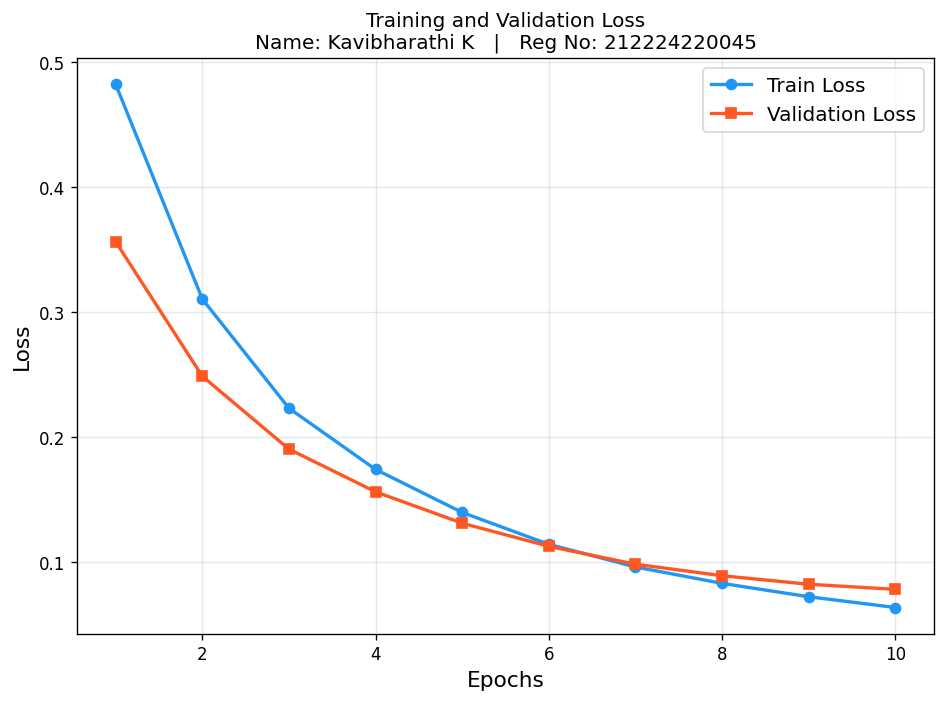

In [16]:
train_model(model, train_loader, test_loader, num_epochs=10)

In [17]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f'Test Accuracy: {accuracy:.4f}')

    cm = confusion_matrix(all_labels, all_preds)
    print("Name: Kavibharathi K       ")
    print("Register Number: 212224220045        ")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=train_dataset.classes,
                yticklabels=train_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("Name: Kavibharathi K        ")
    print("Register Number: 212224220045       ")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Test Accuracy: 0.9915
Name: Kavibharathi K       
Register Number: 212224220045        


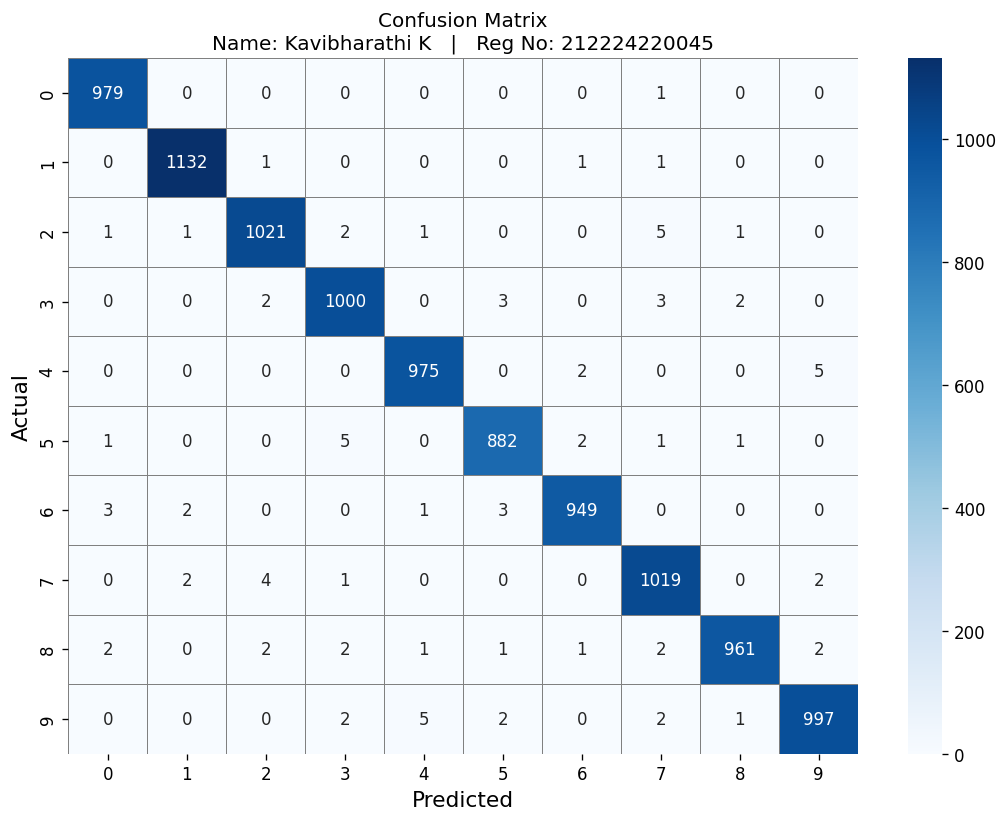

Name: Kavibharathi K        
Register Number: 212224220045       
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


In [18]:
test_model(model, test_loader)

In [19]:
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    with torch.no_grad():
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)
        prob = torch.sigmoid(output)
        predicted = (prob > 0.5).int().item()

    class_names = dataset.classes
    image_to_display = transforms.ToPILImage()(image)
    plt.figure(figsize=(4, 4))
    plt.imshow(image_to_display)
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted]}')
    plt.axis('off')
    plt.show()

    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted]}')

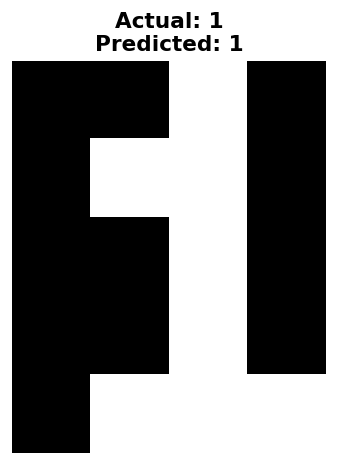

Actual: 1, Predicted: 1


In [20]:
predict_image(model, image_index=55, dataset=test_dataset)

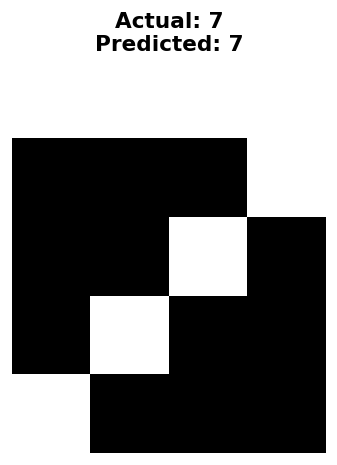

Actual: 7, Predicted: 7


In [21]:
predict_image(model, image_index=25, dataset=test_dataset)